In [1]:
# ============================================================
# CELL 0 — ENVIRONMENT SETUP (run this first, do not modify)
# ============================================================
# Notebook   : notebooks/06_evaluation.ipynb
# Target     : Google Colab | GPU: T4 | RAM: 12GB+
# Estimated runtime: 10–15 minutes
# Dependency : Phase 5 must be complete (model on HF Hub or Drive)
# ============================================================
import os
import sys

# --- Force HuggingFace cache to /tmp (NOT Drive) ---
os.environ["TRANSFORMERS_CACHE"]  = "/tmp/hf_cache"
os.environ["HF_HOME"]             = "/tmp/hf_cache"
os.environ["HF_DATASETS_CACHE"]   = "/tmp/hf_datasets_cache"

# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
DRIVE_ROOT = "/content/drive/MyDrive/HateSpeech_NLP"

# --- Clone or pull Git repository ---
REPO_URL  = "https://github.com/thong7d/hate-speech-detection.git"
REPO_NAME = "hate-speech-detection"
REPO_PATH = f"/content/{REPO_NAME}"

if not os.path.exists(REPO_PATH):
    print("Cloning repository...")
    ret = os.system(f"git clone {REPO_URL} {REPO_PATH}")
    assert ret == 0, "❌ git clone failed!"
else:
    print("Repository found. Pulling latest changes...")
    os.system(f"cd {REPO_PATH} && git pull origin main")

# --- Install package and dependencies ---
os.system(f"pip install -q -e {REPO_PATH}")

SRC_PATH = f"{REPO_PATH}/src"
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

os.system(f"pip install -q -r {REPO_PATH}/requirements.txt")

# --- Verify Drive root ---
assert os.path.isdir(DRIVE_ROOT), (
    f"❌ Drive root not found: {DRIVE_ROOT}\n"
    "   Ensure your Drive folder is named 'HateSpeech_NLP'."
)

print("=" * 55)
print("✅ Environment setup complete.")
print(f"   REPO_PATH  : {REPO_PATH}")
print(f"   DRIVE_ROOT : {DRIVE_ROOT}")
print(f"   SRC_PATH   : {SRC_PATH}")
print(f"   Python     : {sys.version.split()[0]}")
print("=" * 55)


Mounted at /content/drive
Cloning repository...
✅ Environment setup complete.
   REPO_PATH  : /content/hate-speech-detection
   DRIVE_ROOT : /content/drive/MyDrive/HateSpeech_NLP
   SRC_PATH   : /content/hate-speech-detection/src
   Python     : 3.12.13


In [2]:
# ============================================================
# CELL 1 — LOAD FINE-TUNED MODEL
# ============================================================
# Strategy: Try HF Hub first → fallback to Drive if Hub fails.
# This ensures the notebook works even without internet access
# to HuggingFace (e.g., Hub rate-limiting or token issues).
#
# Input:
#   - cfg.hf_model_id      : "thong7d/vihsd-xlmr-hate-speech"
#   - cfg.models.final_hf_dir : Drive path to local model copy
# Output:
#   - model       : AutoModelForSequenceClassification (eval, on GPU)
#   - tokenizer   : AutoTokenizer (XLM-RoBERTa vocab)
#   - device      : torch.device (cuda)
#   - model_source: str (actual source used, for report traceability)
# ============================================================
import gc
import torch
from omegaconf import OmegaConf
from transformers import AutoModelForSequenceClassification, AutoTokenizer


def resolve_path(template_path) -> str:
    """Resolve {drive_root} placeholder. Handles str and nested OmegaConf."""
    if isinstance(template_path, str):
        return template_path.replace("{drive_root}", DRIVE_ROOT)
    if hasattr(template_path, "values"):
        for v in template_path.values():
            return resolve_path(v)
    return str(template_path)


# --- Load config ---
cfg = OmegaConf.load(f"{REPO_PATH}/configs/paths.yaml")

HF_MODEL_ID   = str(cfg.hf_model_id)          # "thong7d/vihsd-xlmr-hate-speech"
FINAL_HF_DIR  = resolve_path(cfg.models.final_hf_dir)
MAX_LENGTH    = int(cfg.training.max_length)   # 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda", (
    "❌ No GPU found! Go to Runtime → Change runtime type → T4 GPU."
)
print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# --- Attempt 1: Load from HuggingFace Hub ---
model_source = None

if HF_MODEL_ID:
    try:
        print(f"\n📥 Attempting to load from HuggingFace Hub: {HF_MODEL_ID}")
        tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_ID)
        model     = AutoModelForSequenceClassification.from_pretrained(HF_MODEL_ID)
        model_source = HF_MODEL_ID
        print(f"   ✅ Loaded from HF Hub.")
    except Exception as e:
        print(f"   ⚠️  HF Hub load failed: {e}")
        print(f"   Falling back to Drive...")
        model_source = None
else:
    print("ℹ️  hf_model_id is empty → skipping HF Hub, loading from Drive.")

# --- Attempt 2: Fallback to Drive ---
if model_source is None:
    assert os.path.isdir(FINAL_HF_DIR), (
        f"❌ Drive model not found at: {FINAL_HF_DIR}\n"
        "   Phase 5 must be completed first (Cell 7 saves model to Drive)."
    )
    print(f"\n📥 Loading model from Drive: {FINAL_HF_DIR}")
    tokenizer = AutoTokenizer.from_pretrained(FINAL_HF_DIR)
    model     = AutoModelForSequenceClassification.from_pretrained(FINAL_HF_DIR)
    model_source = FINAL_HF_DIR
    print(f"   ✅ Loaded from Drive.")

# --- Move to GPU and set eval mode ---
model = model.to(device)
model.eval()                    # Disable dropout; use running stats in BatchNorm

param_count_M = model.num_parameters() / 1e6

print()
print("=" * 55)
print("✅ Model ready for inference.")
print(f"   Source     : {model_source}")
print(f"   Parameters : {param_count_M:.1f}M")
print(f"   Device     : {device}")
print(f"   Max length : {MAX_LENGTH}")
print("=" * 55)

gc.collect()
torch.cuda.empty_cache()


✅ GPU: Tesla T4
ℹ️  hf_model_id is empty → skipping HF Hub, loading from Drive.

📥 Loading model from Drive: /content/drive/MyDrive/HateSpeech_NLP/models/xlmr_vihsd/final_hf


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

   ✅ Loaded from Drive.

✅ Model ready for inference.
   Source     : /content/drive/MyDrive/HateSpeech_NLP/models/xlmr_vihsd/final_hf
   Parameters : 278.0M
   Device     : cuda
   Max length : 128


In [3]:
# ============================================================
# CELL 2 — BATCH INFERENCE ON TEST SET
# ============================================================
# Uses DataLoader with batch_size=64 for fast GPU inference.
# num_workers=0 is mandatory on Colab (avoids shared memory crash).
#
# Input:
#   - test_df  : pandas DataFrame (columns: text, label)
#   - model    : fine-tuned model in eval mode on GPU
#   - tokenizer: XLM-RoBERTa tokenizer
# Output:
#   - y_true : np.ndarray shape (N,) — ground truth integer labels
#   - y_pred : np.ndarray shape (N,) — argmax predicted labels
#   - y_prob : np.ndarray shape (N, 3) — softmax probabilities per class
# ============================================================
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from data.dataset import ViHSDDataset   # src/data/dataset.py

# --- Load test split ---
test_path = resolve_path(cfg.data.test_processed)
print(f"Loading test data from: {test_path}")
test_df = pd.read_parquet(test_path)

# Schema guard: ensure required columns exist
assert "text"  in test_df.columns, f"❌ 'text' column missing.  Found: {list(test_df.columns)}"
assert "label" in test_df.columns, f"❌ 'label' column missing. Found: {list(test_df.columns)}"

print(f"✅ Test set loaded: {len(test_df):,} rows")
print(f"   Label distribution: {test_df['label'].value_counts().sort_index().to_dict()}")

# --- Build ViHSDDataset ---
test_dataset = ViHSDDataset(
    texts=test_df["text"].tolist(),
    labels=test_df["label"].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
)

# --- DataLoader (batch_size=64 for inference speed; num_workers=0 mandatory) ---
test_loader = DataLoader(
    test_dataset,
    batch_size=64,        # Larger batch is safe for inference-only (no gradients stored)
    shuffle=False,        # MUST be False: preserve order to align with test_df rows
    num_workers=0,        # MANDATORY on Colab (shared memory limit)
    pin_memory=False,     # Disable: not needed without num_workers > 0
)

# --- Inference loop ---
all_preds  = []
all_probs  = []
all_labels = []

print(f"\n🔍 Running inference on {len(test_dataset):,} samples...")
print(f"   Batch size : 64 | Num batches : {len(test_loader)}")

with torch.no_grad():   # Disable gradient computation (saves VRAM + speeds up ~2x)
    for batch_idx, batch in enumerate(test_loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"]            # keep on CPU for collection

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits                    # shape: (batch, 3)

        probs = torch.softmax(logits, dim=-1).cpu().numpy()   # (batch, 3)
        preds = np.argmax(probs, axis=-1)                     # (batch,)

        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

        # Progress print every 10 batches
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(test_loader):
            done = (batch_idx + 1) * 64
            print(f"   Processed: {min(done, len(test_dataset)):,} / {len(test_dataset):,} samples")

# --- Convert to numpy ---
y_true = np.array(all_labels, dtype=np.int64)
y_pred = np.array(all_preds,  dtype=np.int64)
y_prob = np.array(all_probs,  dtype=np.float32)   # shape: (N, 3)

# --- Sanity checks ---
assert y_true.shape == y_pred.shape == (len(test_df),), \
    f"❌ Shape mismatch: y_true={y_true.shape}, y_pred={y_pred.shape}"
assert y_prob.shape == (len(test_df), 3), \
    f"❌ y_prob shape error: {y_prob.shape}"
assert set(np.unique(y_pred)).issubset({0, 1, 2}), \
    f"❌ Unexpected prediction labels: {np.unique(y_pred)}"

print()
print("=" * 55)
print(f"✅ Inference complete.")
print(f"   y_true shape : {y_true.shape}")
print(f"   y_pred shape : {y_pred.shape}")
print(f"   y_prob shape : {y_prob.shape}  (N × 3 class probabilities)")
print(f"   Unique preds : {np.unique(y_pred).tolist()}")
print(f"   Accuracy     : {(y_true == y_pred).mean():.4f}")
print("=" * 55)

# --- Mandatory cleanup ---
gc.collect()
torch.cuda.empty_cache()
print("🧹 Memory cleaned.")


Loading test data from: /content/drive/MyDrive/HateSpeech_NLP/data/processed/test.parquet
✅ Test set loaded: 6,650 rows
   Label distribution: {0: 5518, 1: 444, 2: 688}

🔍 Running inference on 6,650 samples...
   Batch size : 64 | Num batches : 104
   Processed: 640 / 6,650 samples
   Processed: 1,280 / 6,650 samples
   Processed: 1,920 / 6,650 samples
   Processed: 2,560 / 6,650 samples
   Processed: 3,200 / 6,650 samples
   Processed: 3,840 / 6,650 samples
   Processed: 4,480 / 6,650 samples
   Processed: 5,120 / 6,650 samples
   Processed: 5,760 / 6,650 samples
   Processed: 6,400 / 6,650 samples
   Processed: 6,650 / 6,650 samples

✅ Inference complete.
   y_true shape : (6650,)
   y_pred shape : (6650,)
   y_prob shape : (6650, 3)  (N × 3 class probabilities)
   Unique preds : [0, 1, 2]
   Accuracy     : 0.8674
🧹 Memory cleaned.


In [4]:
# ============================================================
# CELL 3 — FULL METRICS COMPUTATION & ATOMIC REPORT SAVE
# ============================================================
# Calls compute_full_metrics() and save_metrics_atomic() from
# src/evaluation/evaluate.py — the project's single source of
# truth for all metric computation.
#
# Input:
#   - y_true : np.ndarray  (N,)    — ground truth labels
#   - y_pred : np.ndarray  (N,)    — predicted labels
#   - y_prob : np.ndarray  (N, 3)  — class probabilities
# Output:
#   - metrics : dict (macro_f1, f1_per_class, auc_roc_macro,
#                     classification_report, confusion_matrix)
#   - {DRIVE_ROOT}/results/finetune_report.json   (atomic write)
# ============================================================
import json
from evaluation.evaluate import compute_full_metrics, save_metrics_atomic

# --- Compute all metrics ---
print("Computing full evaluation metrics...")
metrics = compute_full_metrics(y_true, y_pred, y_prob)

# --- Load baseline metrics for side-by-side comparison ---
baseline_path = resolve_path(cfg.results.baseline_report)
baseline_macro_f1 = "N/A"

if os.path.exists(baseline_path):
    try:
        with open(baseline_path, "r") as f:
            baseline_data = json.load(f)
        # Handle multiple possible key names from Phase 4
        baseline_macro_f1 = (
            baseline_data.get("macro_f1")
            or baseline_data.get("f1_macro")
            or baseline_data.get("test_macro_f1")
            or "N/A"
        )
    except Exception as e:
        print(f"⚠️  Could not read baseline report: {e}")
else:
    print(f"⚠️  Baseline report not found at: {baseline_path}")

# --- Print full report ---
cr = metrics["classification_report"]
print()
print("=" * 65)
print("📊 FULL EVALUATION REPORT — Fine-tuned XLM-RoBERTa on ViHSD Test Set")
print("=" * 65)

print(f"\n{'Metric':<28} {'Baseline (TF-IDF+LR)':>22} {'XLM-RoBERTa':>14}")
print("-" * 65)

ft_macro = metrics["macro_f1"]
print(f"{'Macro F1':<28} {str(baseline_macro_f1):>22} {ft_macro:>14.4f}")

for label_name in ["CLEAN", "OFFENSIVE", "HATE"]:
    ft_f1 = metrics["f1_per_class"].get(label_name, "N/A")
    print(f"{'F1 — ' + label_name:<28} {'N/A':>22} {ft_f1:>14.4f}")

auc = metrics.get("auc_roc_macro", "N/A")
print(f"{'AUC-ROC (macro OvR)':<28} {'N/A':>22} {str(auc):>14}")
print("-" * 65)

# Per-class detailed breakdown
print(f"\n📋 Classification Report:")
print(f"   {'':>12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
for lname in ["CLEAN", "OFFENSIVE", "HATE"]:
    row = cr.get(lname, {})
    print(
        f"   {lname:>12}"
        f" {row.get('precision', 0):>10.4f}"
        f" {row.get('recall', 0):>10.4f}"
        f" {row.get('f1-score', 0):>10.4f}"
        f" {int(row.get('support', 0)):>10}"
    )
print()

# Improvement over baseline
try:
    improvement = float(ft_macro) - float(baseline_macro_f1)
    sign = "+" if improvement >= 0 else ""
    print(f"   📈 Improvement over baseline: {sign}{improvement:.4f} Macro F1")
    if improvement >= 0.10:
        print("   🎉 Excellent! >10% improvement achieved.")
    elif improvement >= 0.05:
        print("   ✅ Good improvement (5–10%).")
    else:
        print("   ⚠️  Small improvement (<5%). Review class weights or LR.")
except (ValueError, TypeError):
    pass

print("=" * 65)

# --- Atomic save to Drive (uses shutil.move to avoid Cross-device link error) ---
finetune_report_path = resolve_path(cfg.results.finetune_report)
save_metrics_atomic(metrics, finetune_report_path)
print(f"\n✅ Full report saved (atomic): {finetune_report_path}")


Computing full evaluation metrics...

📊 FULL EVALUATION REPORT — Fine-tuned XLM-RoBERTa on ViHSD Test Set

Metric                         Baseline (TF-IDF+LR)    XLM-RoBERTa
-----------------------------------------------------------------
Macro F1                         0.6129122982979406         0.6461
F1 — CLEAN                                      N/A         0.9362
F1 — OFFENSIVE                                  N/A         0.4113
F1 — HATE                                       N/A         0.5909
AUC-ROC (macro OvR)                             N/A         0.8788
-----------------------------------------------------------------

📋 Classification Report:
                 Precision     Recall         F1    Support
          CLEAN     0.9316     0.9407     0.9362       5518
      OFFENSIVE     0.4328     0.3919     0.4113        444
           HATE     0.5962     0.5858     0.5909        688

   📈 Improvement over baseline: +0.0332 Macro F1
   ⚠️  Small improvement (<5%). Review clas

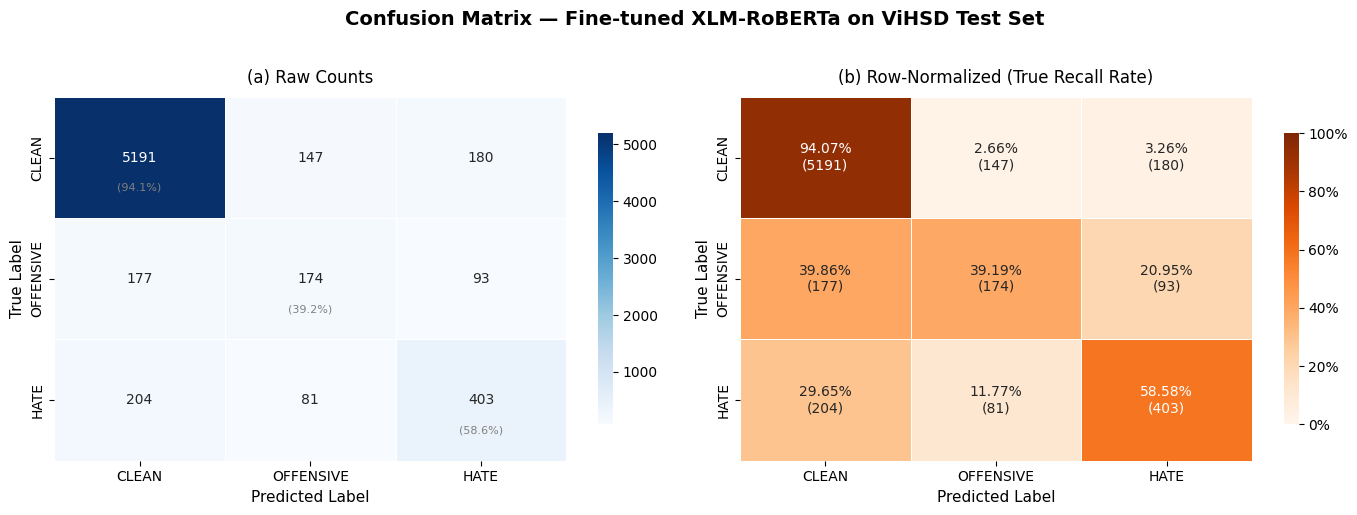

✅ Confusion matrix saved: /content/drive/MyDrive/HateSpeech_NLP/results/confusion_matrix_finetune.png

📖 Reading Guide:
   Diagonal cells = Correct predictions (want high %)
   Row = True class | Column = Predicted class
   CLEAN  recall : 94.07%   (miss as OFF: 2.66%, HATE: 3.26%)
   OFFENS recall : 39.19%   (miss as CLN: 39.86%, HATE: 20.95%)
   HATE   recall : 58.58%   (miss as CLN: 29.65%, OFF:  11.77%)


In [5]:
# ============================================================
# CELL 4 — CONFUSION MATRIX VISUALIZATION
# ============================================================
# Plots two side-by-side confusion matrices:
#   Left : Raw counts     (understand volume of each error type)
#   Right: Row-normalized (understand rate — comparable across classes)
#
# Input:
#   - y_true : np.ndarray (N,) — ground truth labels
#   - y_pred : np.ndarray (N,) — predicted labels
# Output:
#   - Figure displayed inline
#   - {DRIVE_ROOT}/results/confusion_matrix_finetune.png saved to Drive
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABEL_NAMES = ["CLEAN", "OFFENSIVE", "HATE"]

# --- Compute matrices ---
cm_count = confusion_matrix(y_true, y_pred)                              # Raw counts
cm_norm  = cm_count.astype("float") / cm_count.sum(axis=1, keepdims=True)  # Row-normalized

# --- Figure layout ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Confusion Matrix — Fine-tuned XLM-RoBERTa on ViHSD Test Set",
    fontsize=14, fontweight="bold", y=1.02,
)

# --- Left: Raw Count matrix ---
sns.heatmap(
    cm_count,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    ax=axes[0],
    cbar_kws={"shrink": 0.8},
)
axes[0].set_title("(a) Raw Counts", fontsize=12, pad=10)
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)

# Annotate diagonal cells with accuracy rate for quick reading
for i in range(len(LABEL_NAMES)):
    rate = cm_norm[i, i]
    axes[0].text(
        i + 0.5, i + 0.75,
        f"({rate:.1%})",
        ha="center", va="center",
        fontsize=8, color="gray",
    )

# --- Right: Row-normalized matrix ---
annot_matrix = np.array(
    [[f"{cm_norm[i, j]:.2%}\n({cm_count[i, j]})" for j in range(3)] for i in range(3)]
)
sns.heatmap(
    cm_norm,
    annot=annot_matrix,
    fmt="",           # fmt="" because annot already contains strings
    cmap="Oranges",
    linewidths=0.5,
    vmin=0.0, vmax=1.0,
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    ax=axes[1],
    cbar_kws={"shrink": 0.8, "format": mticker.PercentFormatter(xmax=1)},
)
axes[1].set_title("(b) Row-Normalized (True Recall Rate)", fontsize=12, pad=10)
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Label", fontsize=11)

plt.tight_layout()

# --- Save to Drive ---
cm_save_path = f"{DRIVE_ROOT}/results/confusion_matrix_finetune.png"
os.makedirs(os.path.dirname(cm_save_path), exist_ok=True)
fig.savefig(cm_save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Confusion matrix saved: {cm_save_path}")

# --- Print quick reading guide ---
print()
print("📖 Reading Guide:")
print("   Diagonal cells = Correct predictions (want high %)")
print("   Row = True class | Column = Predicted class")
print(f"   CLEAN  recall : {cm_norm[0,0]:.2%}   (miss as OFF: {cm_norm[0,1]:.2%}, HATE: {cm_norm[0,2]:.2%})")
print(f"   OFFENS recall : {cm_norm[1,1]:.2%}   (miss as CLN: {cm_norm[1,0]:.2%}, HATE: {cm_norm[1,2]:.2%})")
print(f"   HATE   recall : {cm_norm[2,2]:.2%}   (miss as CLN: {cm_norm[2,0]:.2%}, OFF:  {cm_norm[2,1]:.2%})")


In [6]:
# ============================================================
# CELL 5 — ERROR ANALYSIS & CSV EXPORT
# ============================================================
# Classifies every prediction into one of 5 error types:
#   CORRECT          : true == pred
#   FALSE_POSITIVE   : true=CLEAN, pred=OFFENSIVE or HATE
#   FALSE_NEGATIVE   : true=OFFENSIVE or HATE, pred=CLEAN
#   OFF_HATE_CONFUSION: {true, pred} == {OFFENSIVE, HATE}
#   OTHER            : any remaining misclassifications
#
# Input:
#   - test_df : original test DataFrame (columns: text, label)
#   - y_true  : np.ndarray (N,)
#   - y_pred  : np.ndarray (N,)
#   - y_prob  : np.ndarray (N, 3)
# Output:
#   - analysis_df          : full DataFrame with error tags
#   - errors_df            : errors-only subset (CORRECT excluded)
#   - {DRIVE_ROOT}/results/error_analysis.csv saved to Drive
# ============================================================
import pandas as pd

LABEL_MAP   = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}
LABEL_NAMES = ["CLEAN", "OFFENSIVE", "HATE"]

# --- Build analysis DataFrame ---
analysis_df = test_df[["text", "label"]].copy().reset_index(drop=True)
analysis_df["pred_label"]      = y_pred
analysis_df["true_label_name"] = analysis_df["label"].map(LABEL_MAP)
analysis_df["pred_label_name"] = analysis_df["pred_label"].map(LABEL_MAP)
analysis_df["confidence"]      = y_prob.max(axis=1).round(4)
analysis_df["prob_clean"]      = y_prob[:, 0].round(4)
analysis_df["prob_offensive"]  = y_prob[:, 1].round(4)
analysis_df["prob_hate"]       = y_prob[:, 2].round(4)
analysis_df["text_length"]     = analysis_df["text"].str.split().str.len()


# --- Error classification function ---
def classify_error(row) -> str:
    """
    Assign one of 5 mutually exclusive error type labels.

    Priority order (top → bottom):
      1. CORRECT           — true == pred
      2. FALSE_POSITIVE    — innocuous text flagged as harmful
      3. FALSE_NEGATIVE    — harmful text missed (most dangerous)
      4. OFF_HATE_CONFUSION— model confuses severity level
      5. OTHER             — any remaining case (shouldn't happen
                             given the 3-class setup, but guards against
                             future label changes)
    """
    t, p = int(row["label"]), int(row["pred_label"])

    if t == p:
        return "CORRECT"
    if t == 0 and p in (1, 2):
        return "FALSE_POSITIVE"       # CLEAN → predicted OFFENSIVE or HATE
    if t in (1, 2) and p == 0:
        return "FALSE_NEGATIVE"       # OFFENSIVE/HATE → predicted CLEAN
    if {t, p} == {1, 2}:
        return "OFF_HATE_CONFUSION"   # Confused severity (OFF↔HATE)
    return "OTHER"


analysis_df["error_type"] = analysis_df.apply(classify_error, axis=1)

# --- Summary statistics ---
error_counts = analysis_df["error_type"].value_counts()
total        = len(analysis_df)
correct      = error_counts.get("CORRECT", 0)

print("=" * 65)
print("📊 ERROR ANALYSIS SUMMARY")
print("=" * 65)
print(f"   Total samples  : {total:,}")
print(f"   Correct        : {correct:,}  ({correct/total:.2%})")
print()
print(f"   {'Error Type':<25} {'Count':>8} {'Rate':>10}")
print(f"   {'-'*43}")
for etype in ["FALSE_POSITIVE", "FALSE_NEGATIVE", "OFF_HATE_CONFUSION", "OTHER"]:
    count = error_counts.get(etype, 0)
    print(f"   {etype:<25} {count:>8,} {count/total:>10.2%}")
print("=" * 65)

# --- Short text vs long text accuracy ---
short_mask = analysis_df["text_length"] < 10
long_mask  = analysis_df["text_length"] >= 10
short_acc  = (analysis_df.loc[short_mask, "error_type"] == "CORRECT").mean()
long_acc   = (analysis_df.loc[long_mask,  "error_type"] == "CORRECT").mean()

print(f"\n📐 Text Length Analysis:")
print(f"   Short texts (< 10 words)  : {short_mask.sum():,} samples | Accuracy = {short_acc:.2%}")
print(f"   Long  texts (≥ 10 words)  : {long_mask.sum():,} samples  | Accuracy = {long_acc:.2%}")
if long_acc > short_acc:
    print(f"   ℹ️  Longer texts are easier (+{long_acc - short_acc:.2%}), consistent with XLM-R ability to use broader context.")
else:
    print(f"   ℹ️  Short texts are easier — may indicate noisy long text in dataset.")

# --- Confidence analysis per error type ---
print(f"\n🎯 Mean Confidence by Error Type:")
for etype, group in analysis_df.groupby("error_type"):
    mean_conf = group["confidence"].mean()
    print(f"   {etype:<25} mean confidence = {mean_conf:.4f}")

# --- Example errors: top 3 per error type ---
print(f"\n📝 Example Errors (top 3 per type, sorted by lowest confidence):")
for etype in ["FALSE_POSITIVE", "FALSE_NEGATIVE", "OFF_HATE_CONFUSION"]:
    subset = (
        analysis_df[analysis_df["error_type"] == etype]
        .sort_values("confidence")
        .head(3)
    )
    if len(subset) == 0:
        continue
    print(f"\n   [{etype}]")
    for _, row in subset.iterrows():
        preview = row["text"][:80].replace("\n", " ")
        print(f"     True: {row['true_label_name']:<10} Pred: {row['pred_label_name']:<10} Conf: {row['confidence']:.3f}")
        print(f"     Text: {preview!r}")

# --- Save errors to Drive ---
# Save only misclassified rows (CORRECT rows excluded) to keep CSV manageable
errors_df = analysis_df[analysis_df["error_type"] != "CORRECT"][[
    "text", "true_label_name", "pred_label_name", "error_type",
    "confidence", "prob_clean", "prob_offensive", "prob_hate", "text_length",
]].copy()

error_analysis_path = resolve_path(cfg.results.error_analysis)
os.makedirs(os.path.dirname(error_analysis_path), exist_ok=True)
errors_df.to_csv(error_analysis_path, index=False, encoding="utf-8-sig")

print(f"\n✅ Error analysis saved: {error_analysis_path}")
print(f"   ({len(errors_df):,} misclassified rows exported)")


📊 ERROR ANALYSIS SUMMARY
   Total samples  : 6,650
   Correct        : 5,768  (86.74%)

   Error Type                   Count       Rate
   -------------------------------------------
   FALSE_POSITIVE                 327      4.92%
   FALSE_NEGATIVE                 381      5.73%
   OFF_HATE_CONFUSION             174      2.62%
   OTHER                            0      0.00%

📐 Text Length Analysis:
   Short texts (< 10 words)  : 3,861 samples | Accuracy = 90.00%
   Long  texts (≥ 10 words)  : 2,789 samples  | Accuracy = 82.22%
   ℹ️  Short texts are easier — may indicate noisy long text in dataset.

🎯 Mean Confidence by Error Type:
   CORRECT                   mean confidence = 0.9913
   FALSE_NEGATIVE            mean confidence = 0.9619
   FALSE_POSITIVE            mean confidence = 0.9353
   OFF_HATE_CONFUSION        mean confidence = 0.9497

📝 Example Errors (top 3 per type, sorted by lowest confidence):

   [FALSE_POSITIVE]
     True: CLEAN      Pred: HATE       Conf: 0.482
    

In [7]:
# ============================================================
# CELL 6 — BASELINE vs FINE-TUNED COMPARISON TABLE
# ============================================================
# Purpose: Generate the definitive comparison table for Report Section 5.
# Also measures real inference latency on a single sample (T4 GPU).
#
# Input:
#   - {DRIVE_ROOT}/results/baseline_report.json  (from Phase 4)
#   - {DRIVE_ROOT}/results/finetune_report.json  (from Phase 5 + Cell 3)
#   - model, tokenizer (from Cell 1) for latency measurement
# Output:
#   - Full comparison table printed
#   - Single-sample inference latency measured
# ============================================================
import json
import time
import torch

# --- Load both reports ---
baseline_path  = resolve_path(cfg.results.baseline_report)
finetune_path  = resolve_path(cfg.results.finetune_report)

assert os.path.exists(baseline_path), (
    f"❌ Baseline report not found: {baseline_path}\n"
    "   Ensure Phase 4 completed and saved baseline_report.json."
)
assert os.path.exists(finetune_path), (
    f"❌ Finetune report not found: {finetune_path}\n"
    "   Ensure Cell 3 of this notebook ran successfully."
)

with open(baseline_path,  "r") as f:
    baseline  = json.load(f)
with open(finetune_path,  "r") as f:
    finetune  = json.load(f)


def get_val(d: dict, *keys, default="N/A"):
    """Try multiple key names in order; return first match or default."""
    for k in keys:
        if k in d:
            v = d[k]
            return round(v, 4) if isinstance(v, float) else v
    return default


# --- Extract metrics ---
base_macro = get_val(baseline, "macro_f1", "f1_macro", "test_macro_f1")
ft_macro   = get_val(finetune, "macro_f1", "test_macro_f1")

# Per-class F1
ft_per_class = finetune.get("f1_per_class", {})
base_per_class_report = baseline.get("classification_report", {})

def base_f1_class(label_key: str):
    """Extract per-class F1 from a classification_report dict."""
    if label_key in base_per_class_report:
        return round(base_per_class_report[label_key].get("f1-score", 0), 4)
    return "N/A"

base_f1_clean = base_f1_class("CLEAN")
base_f1_off   = base_f1_class("OFFENSIVE")
base_f1_hate  = base_f1_class("HATE")

ft_f1_clean = ft_per_class.get("CLEAN",     get_val(finetune, "test_f1_clean",     default="N/A"))
ft_f1_off   = ft_per_class.get("OFFENSIVE", get_val(finetune, "test_f1_offensive", default="N/A"))
ft_f1_hate  = ft_per_class.get("HATE",      get_val(finetune, "test_f1_hate",      default="N/A"))

ft_auc      = get_val(finetune, "auc_roc_macro")
base_auc    = "N/A"

# --- Measure real inference latency (single sample, warm-up included) ---
sample_text = "Bài viết rất hay, cảm ơn tác giả!"
enc = tokenizer(
    sample_text, max_length=MAX_LENGTH,
    padding="max_length", truncation=True, return_tensors="pt"
)
input_ids      = enc["input_ids"].to(device)
attention_mask = enc["attention_mask"].to(device)

# Warm-up run (GPU needs 1 forward pass to reach steady state)
with torch.no_grad():
    _ = model(input_ids=input_ids, attention_mask=attention_mask)

# Timed run (average of 20 passes for stability)
latency_runs = 20
torch.cuda.synchronize()   # Ensure previous ops are complete
start = time.perf_counter()
with torch.no_grad():
    for _ in range(latency_runs):
        _ = model(input_ids=input_ids, attention_mask=attention_mask)
torch.cuda.synchronize()
elapsed_ms = (time.perf_counter() - start) * 1000 / latency_runs

ft_latency   = f"~{elapsed_ms:.1f}ms"
base_latency = "~1ms"   # TF-IDF + LR is near-instant even on CPU

# --- Print comparison table ---
W_METRIC = 26
W_BASE   = 22
W_FT     = 14

print()
print("=" * (W_METRIC + W_BASE + W_FT + 8))
print("📊 MODEL COMPARISON TABLE — Report Section 5")
print("=" * (W_METRIC + W_BASE + W_FT + 8))
print(
    f"   {'Metric':<{W_METRIC}}"
    f" {'Baseline (TF-IDF+LR)':>{W_BASE}}"
    f" {'XLM-RoBERTa (FT)':>{W_FT}}"
)
print(f"   {'-' * (W_METRIC + W_BASE + W_FT + 4)}")

rows = [
    ("Macro F1",               str(base_macro),   str(ft_macro)),
    ("F1 — CLEAN",             str(base_f1_clean),str(ft_f1_clean)),
    ("F1 — OFFENSIVE",         str(base_f1_off),  str(ft_f1_off)),
    ("F1 — HATE",              str(base_f1_hate), str(ft_f1_hate)),
    ("AUC-ROC (macro OvR)",    str(base_auc),     str(ft_auc)),
    ("Inference latency/sample",base_latency,      ft_latency),
    ("Train time (est.)",      "< 1 min (CPU)",   "45–60 min (T4)"),
    ("Model size",             "~50 MB (.pkl)",   "~280 MB (HF format)"),
]

for metric, base_val, ft_val in rows:
    print(
        f"   {metric:<{W_METRIC}}"
        f" {base_val:>{W_BASE}}"
        f" {ft_val:>{W_FT}}"
    )

print("=" * (W_METRIC + W_BASE + W_FT + 8))

# Compute absolute improvement
try:
    delta = float(ft_macro) - float(base_macro)
    sign  = "+" if delta >= 0 else ""
    print(f"\n   📈 Absolute Macro F1 improvement: {sign}{delta:.4f}")
    pct_gain = delta / float(base_macro) * 100
    print(f"   📈 Relative improvement          : {sign}{pct_gain:.1f}%")
except (ValueError, TypeError):
    pass

print()
print("=" * 65)
print("🎉 PHASE 6 COMPLETE!")
print()
print("   Artifacts saved to Drive:")
print(f"   ✅ {resolve_path(cfg.results.finetune_report)}")
print(f"   ✅ {resolve_path(cfg.results.error_analysis)}")
print(f"   ✅ {DRIVE_ROOT}/results/confusion_matrix_finetune.png")
print()
print("   Next step → notebooks/07_deployment.ipynb")
print("=" * 65)



📊 MODEL COMPARISON TABLE — Report Section 5
   Metric                       Baseline (TF-IDF+LR) XLM-RoBERTa (FT)
   ------------------------------------------------------------------
   Macro F1                                   0.6129         0.6461
   F1 — CLEAN                                    N/A         0.9362
   F1 — OFFENSIVE                                N/A         0.4113
   F1 — HATE                                     N/A         0.5909
   AUC-ROC (macro OvR)                           N/A         0.8788
   Inference latency/sample                     ~1ms        ~18.0ms
   Train time (est.)                   < 1 min (CPU) 45–60 min (T4)
   Model size                          ~50 MB (.pkl) ~280 MB (HF format)

   📈 Absolute Macro F1 improvement: +0.0332
   📈 Relative improvement          : +5.4%

🎉 PHASE 6 COMPLETE!

   Artifacts saved to Drive:
   ✅ /content/drive/MyDrive/HateSpeech_NLP/results/finetune_report.json
   ✅ /content/drive/MyDrive/HateSpeech_NLP/results/erro